# Stock Signal Dashboard - Exploratory Data Analysis

## Objective
Understand the data deeply before building any model.
EDA answers the question - what is the data telling us?

---

## Why EDA matters
- A model built on misunderstood data will always fail
- EDA reveals patterns, anomalies, and relationships
- Every decision in feature engineering comes from EDA insights
- In industry, data scientists spend 60% of their time here

---

## What we analyse
1. Load and inspect the raw data
2. Check for missing values
3. Understand price distributions
4. Visualise price history for all 20 stocks
5. Analyse volume patterns
6. Compare sector behavior
7. Check correlations between stocks

> This notebook is read only analysis.
> We do not modify any data here.
> All transformations happen in the next notebook.

In [1]:
# ============================================================
# CELL 1 - Load Libraries and Raw Data
# ============================================================
# We load from CSV not from API
# This ensures consistency across runs
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings - prevent truncated output
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load raw data
raw_data_path = "../data/raw/all_stocks_raw.csv"
df = pd.read_csv(raw_data_path, parse_dates=['Date'])

print("Data loaded successfully!")
print("="*45)
print(f"Rows      : {df.shape[0]}")
print(f"Columns   : {df.shape[1]}")
print(f"Stocks    : {df['Ticker'].nunique()}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print("="*45)
print(f"\nColumn names : {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Data loaded successfully!
Rows      : 30180
Columns   : 7
Stocks    : 20
Date range: 2019-01-02 to 2024-12-30

Column names : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']

First 5 rows:


,Date,Close,High,Low,Open,Volume,Ticker
0,2019-01-02,37.4692,37.6899,36.5937,36.7503,148158800,AAPL
1,2019-01-03,33.7370,34.5745,33.6919,34.1617,365248800,AAPL
2,2019-01-04,35.1772,35.2460,34.1190,34.2922,234428400,AAPL
3,2019-01-07,35.0989,35.3124,34.6172,35.2816,219111200,AAPL
4,2019-01-08,35.7680,36.0219,35.2389,35.4857,164101200,AAPL


## Step 2 - Check for Missing Values

Missing values are one of the most common data quality problems.
In stock data they occur when:
- A stock was not traded on a particular day
- The API failed to return data for certain dates
- A company was not yet listed on the exchange

### Why this matters for our model:
- Missing values in features cause model training to fail
- Incorrectly filled missing values introduce false patterns
- We must understand WHY values are missing before fixing them

In [2]:
# ============================================================
# CELL 2 - Check for Missing Values
# ============================================================
# We check missing values at two levels:
# 1. Overall - across entire dataset
# 2. Per stock - some stocks may have more gaps than others
# ============================================================

print("MISSING VALUE REPORT")
print("="*45)

# Overall missing values
print("\n1. Missing Values Per Column")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct.round(2)
})
print(missing_report.to_string())

# Missing values per stock
print("\n2. Missing Values Per Stock")
missing_per_stock = df.groupby('Ticker').apply(
    lambda x: x.isnull().sum().sum()
)
print(missing_per_stock.to_string())

# Check for duplicate rows
print("\n3. Duplicate Rows")
duplicates = df.duplicated().sum()
print(f"   Total duplicates : {duplicates}")

# Check for duplicate Date + Ticker combinations
dup_date_ticker = df.duplicated(subset=['Date', 'Ticker']).sum()
print(f"   Duplicate Date+Ticker combinations : {dup_date_ticker}")

print(f"\n{'='*45}")
if missing.sum() == 0 and duplicates == 0:
    print("All checks passed! Data is clean.")
else:
    print("Issues found - see above for details.")
print(f"{'='*45}")

MISSING VALUE REPORT

1. Missing Values Per Column
        Missing Count  Missing %
Date                0     0.0000
Close               0     0.0000
High                0     0.0000
Low                 0     0.0000
Open                0     0.0000
Volume              0     0.0000
Ticker              0     0.0000

2. Missing Values Per Stock
Ticker
AAPL     0
ADBE     0
AMZN     0
BAC      0
CRM      0
GOOGL    0
GS       0
JNJ      0
JPM      0
MA       0
META     0
MSFT     0
NFLX     0
NVDA     0
ORCL     0
PFE      0
TSLA     0
UNH      0
V        0
WMT      0

3. Duplicate Rows
   Total duplicates : 0
   Duplicate Date+Ticker combinations : 0

All checks passed! Data is clean.


## Step 3 - Statistical Summary

Descriptive statistics tell us the basic characteristics
of our data before we plot anything.

### What we look for:
- Price ranges across different stocks
- Average volume per stock
- Standard deviation - how volatile is each stock?
- Min and max prices - any extreme outliers?

### Why standard deviation matters here:
A high standard deviation on Close price means
the stock is highly volatile - it swings a lot.
This is important context for our prediction model.

In [3]:
# ============================================================
# CELL 3 - Statistical Summary
# ============================================================
# We analyse statistics at two levels:
# 1. Overall dataset statistics
# 2. Per stock - price range, volatility, average volume
# ============================================================

print("STATISTICAL SUMMARY")
print("="*60)

# Overall statistics
print("\n1. Overall Price Statistics (Close Price)")
print(df.groupby('Ticker')['Close'].describe().round(2).to_string())

print("\n" + "="*60)

# Volatility per stock - standard deviation of daily returns
print("\n2. Volatility Per Stock (Std Dev of Daily Returns)")
print("   Higher number = more volatile stock\n")

volatility = df.groupby('Ticker')['Close'].apply(
    lambda x: x.pct_change().std() * 100
).round(4).sort_values(ascending=False)

volatility_df = pd.DataFrame({
    'Daily Volatility %' : volatility,
    'Category'           : ['High' if v > 2.5 else 
                            'Medium' if v > 1.5 else 
                            'Low' for v in volatility]
})
print(volatility_df.to_string())

print("\n" + "="*60)

# Average daily volume per stock
print("\n3. Average Daily Volume Per Stock")
avg_volume = df.groupby('Ticker')['Volume'].mean().sort_values(
    ascending=False
).apply(lambda x: f"{x:,.0f}")
print(avg_volume.to_string())

print(f"\n{'='*60}")
print("Summary complete!")
print(f"{'='*60}")

STATISTICAL SUMMARY

1. Overall Price Statistics (Close Price)
           count     mean      std      min      25%      50%      75%      max
Ticker                                                                         
AAPL   1509.0000 134.3600  53.8400  33.7400  88.3100 142.6800 171.3500 257.3800
ADBE   1509.0000 440.3900 113.5500 215.7000 341.3100 455.6200 519.6600 688.3700
AMZN   1509.0000 137.1000  36.1900  75.0100  99.2200 140.5700 166.3100 232.9300
BAC    1509.0000  30.3700   6.5500  15.5400  25.0400  29.7500  35.6200  45.9300
CRM    1509.0000 208.1400  50.4000 122.5000 160.4000 205.4400 246.2200 364.1600
GOOGL  1509.0000 108.1600  36.7400  50.8200  73.3000 108.8000 136.3600 195.6400
GS     1509.0000 290.1300 100.5900 116.6200 186.0900 299.9700 343.8800 587.7600
JNJ    1509.0000 137.5600  16.0900  93.4300 124.6100 142.6200 149.6800 164.6800
JPM    1509.0000 128.5800  37.8700  66.7600  98.7400 124.4600 143.0800 242.7600
MA     1509.0000 345.5700  73.3300 173.6500 296.1500 341.

## Inference from Statistical Summary

### Volatility Insights
- TSLA is the most volatile stock at 4.06% daily swing
  This means on a $200 stock, price moves $8 up or down every day
  Harder to predict direction but higher reward when correct

- JNJ and WMT are the most stable at 1.21% and 1.35%
  These are defensive stocks - people buy medicine and groceries
  regardless of economy - so prices are naturally stable
  Easier to predict direction but smaller price moves

- Our model will likely show higher accuracy on low volatility
  stocks and lower accuracy on high volatility stocks
  This is expected and normal - not a model failure

### Volume Insights
- NVDA trades 448 million shares daily - highest in our dataset
  This exploded due to the AI boom in 2023-2024
  High volume = genuine price discovery = better signal quality

- GS and MA trade only 2-3 million shares daily
  Low volume means fewer participants
  Price can be influenced by large institutional trades
  Our volume-based features will be stronger for high volume stocks

### Price Range Insights
- Stocks range from $3 (NVDA minimum) to $688 (ADBE maximum)
  Raw price cannot be used as a feature directly
  We must use returns (percentage changes) instead
  This normalizes all stocks to the same scale

### Key Decisions for Feature Engineering
  Based on this EDA we will:
  1. Use percentage returns not raw prices as features
  2. Include volume change as a feature - it precedes price moves
  3. Normalise all features per stock to handle price differences
  4. Expect model accuracy to vary by stock volatility level

## Step 4 - Price History Visualization

We plot the 5 year price history for all 20 stocks.

### Why visualize price history?
- Numbers alone do not tell the full story
- Charts reveal trends, crashes, and recoveries visually
- We can spot the COVID crash of March 2020 and the
  AI boom of 2023 directly from the chart
- Visual patterns confirm what statistics told us

### What we look for:
- Overall trend direction per stock
- Major crash and recovery events
- Stocks that grew dramatically vs stayed flat
- Sector behavior during market events

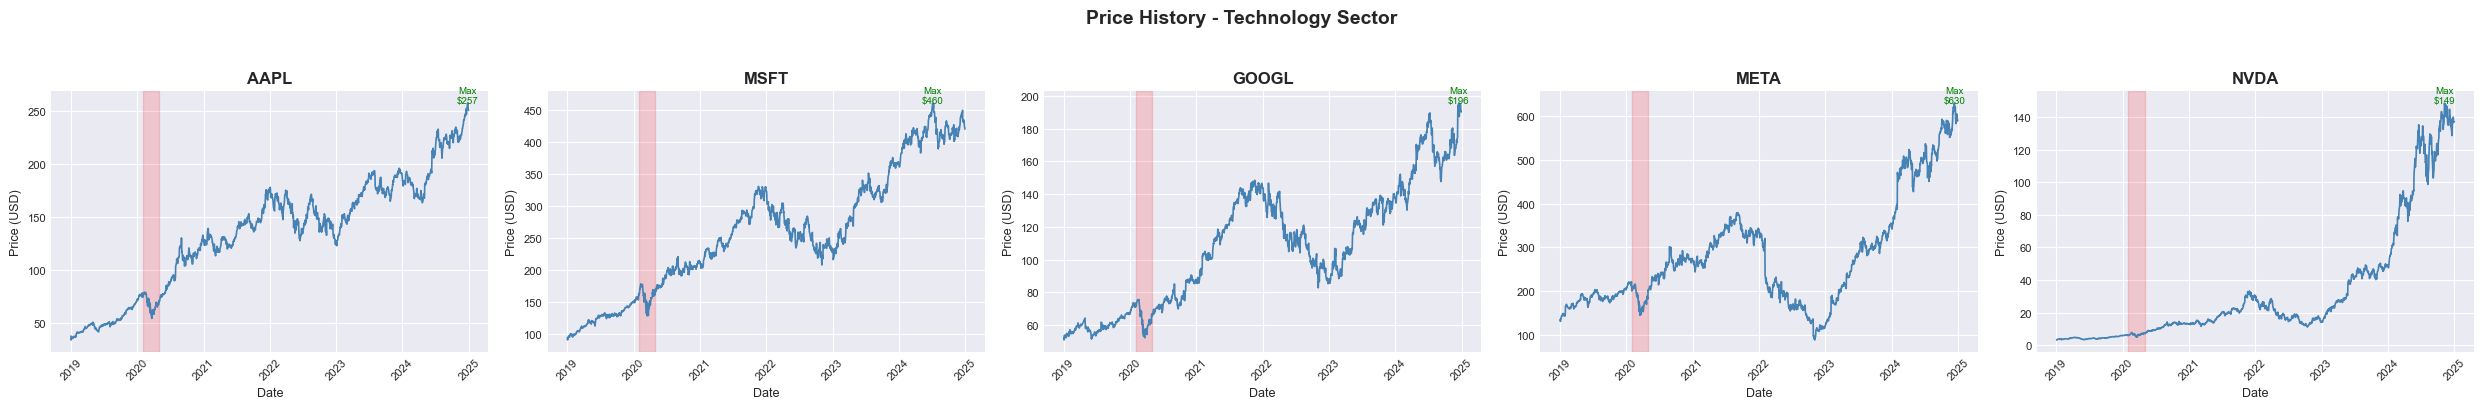

Technology sector plotted and saved.


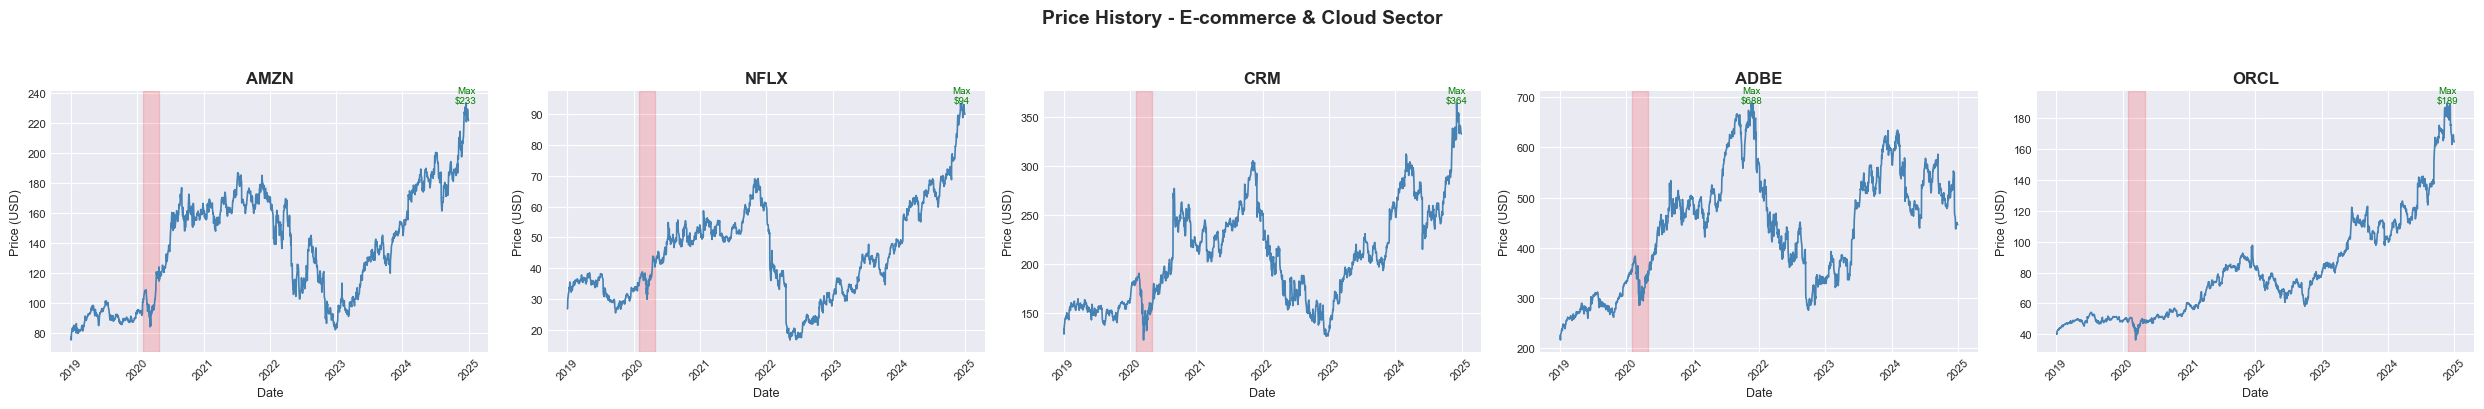

E-commerce & Cloud sector plotted and saved.


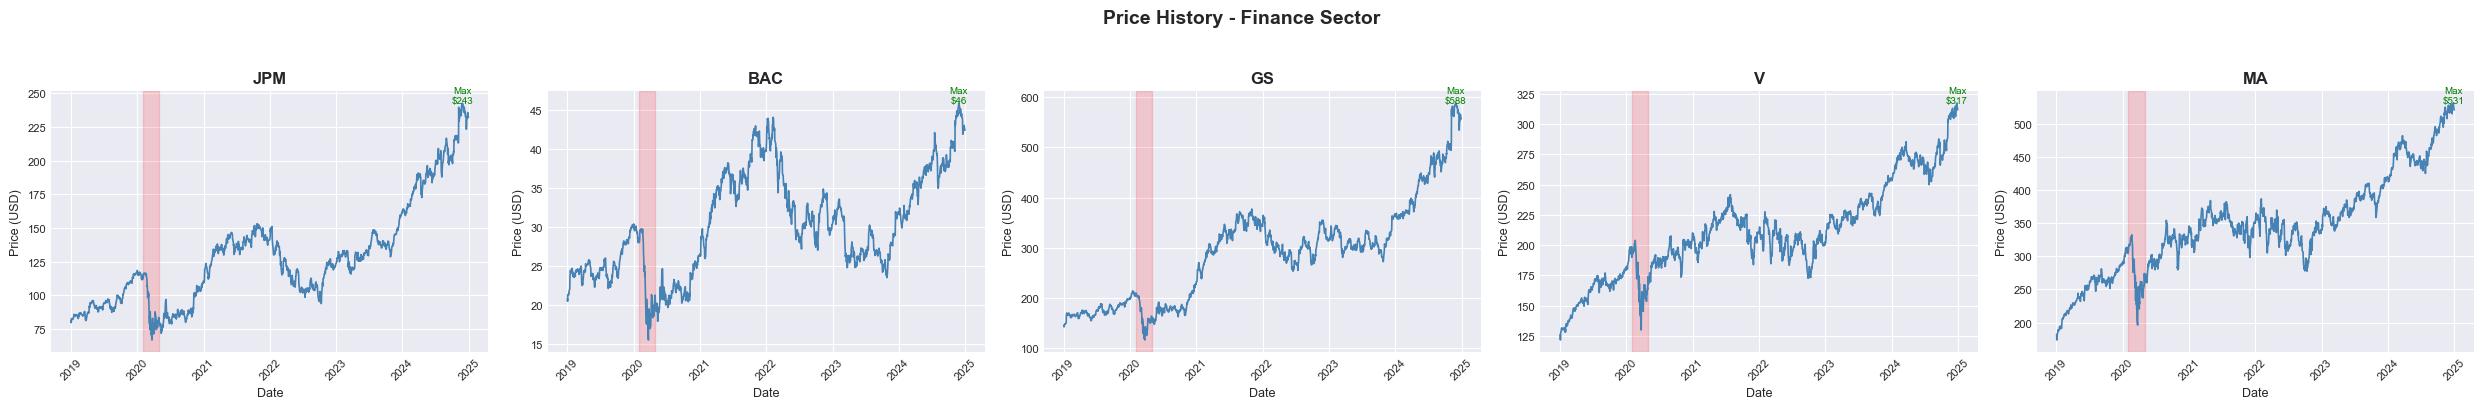

Finance sector plotted and saved.


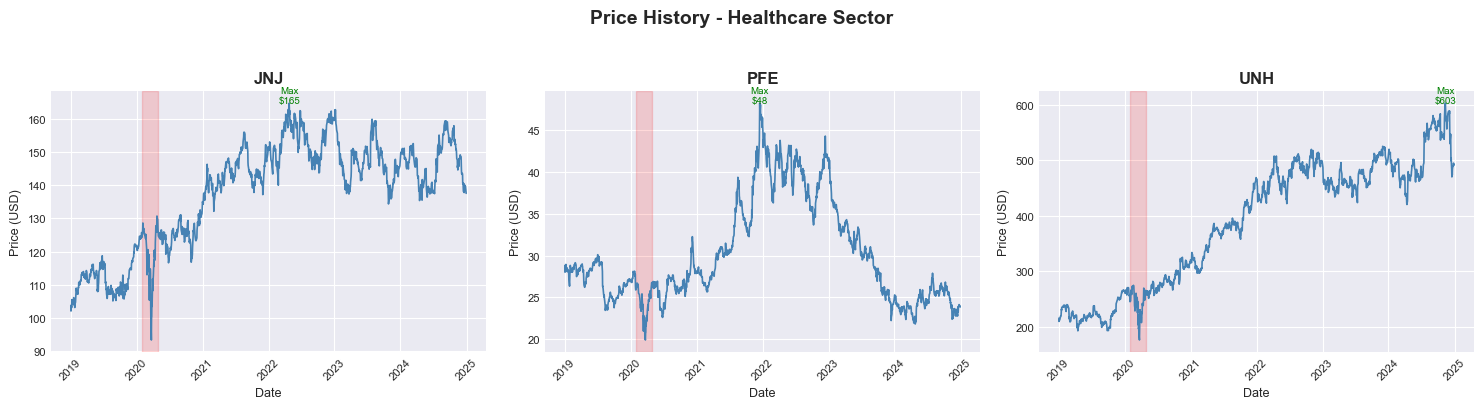

Healthcare sector plotted and saved.


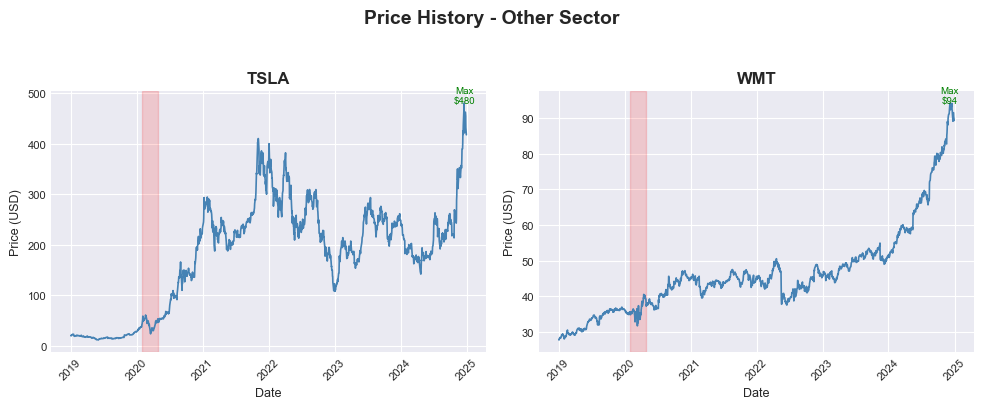

Other sector plotted and saved.


In [4]:
# ============================================================
# CELL 4 - Price History for All 20 Stocks
# ============================================================
# We plot Close price history for all 20 stocks
# Organized by sector so we can compare sector behavior
# ============================================================

# Define sectors for organized plotting
sectors = {
    'Technology'        : ['AAPL', 'MSFT', 'GOOGL', 'META', 'NVDA'],
    'E-commerce & Cloud': ['AMZN', 'NFLX', 'CRM', 'ADBE', 'ORCL'],
    'Finance'           : ['JPM', 'BAC', 'GS', 'V', 'MA'],
    'Healthcare'        : ['JNJ', 'PFE', 'UNH'],
    'Other'             : ['TSLA', 'WMT']
}

# Plot each sector separately
for sector_name, tickers in sectors.items():

    n = len(tickers)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

    # Handle case where only one ticker in sector
    if n == 1:
        axes = [axes]

    fig.suptitle(
        f'Price History - {sector_name} Sector',
        fontsize=14,
        fontweight='bold',
        y=1.02
    )

    for i, ticker in enumerate(tickers):
        # Get data for this ticker
        stock_df = df[df['Ticker'] == ticker].copy()

        ax = axes[i]

        # Plot close price
        ax.plot(
            stock_df['Date'],
            stock_df['Close'],
            linewidth=1.2,
            color='steelblue'
        )

        # Shade the COVID crash period
        ax.axvspan(
            pd.Timestamp('2020-02-01'),
            pd.Timestamp('2020-04-30'),
            alpha=0.15,
            color='red',
            label='COVID crash'
        )

        # Add labels
        ax.set_title(ticker, fontsize=12, fontweight='bold')
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Price (USD)', fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)

        # Add min and max annotations
        max_price = stock_df['Close'].max()
        min_price = stock_df['Close'].min()
        max_date  = stock_df.loc[stock_df['Close'].idxmax(), 'Date']

        ax.annotate(
            f'Max\n${max_price:.0f}',
            xy=(max_date, max_price),
            fontsize=7,
            color='green',
            ha='center'
        )

    plt.tight_layout()
    plt.savefig(
        f'../data/raw/{sector_name.replace(" ", "_")}_price_history.png',
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    print(f"{sector_name} sector plotted and saved.")

## Inference from Price History Charts

### Universal Pattern - COVID Crash (Red Zone 2020)
Every single stock shows a dip in the red highlighted zone.
This confirms the COVID crash of March 2020 was a market-wide event.
After the crash every stock recovered - some faster than others.
Healthcare stocks like UNH recovered fastest - people still need healthcare.
Finance stocks like BAC took longest - banking fears during recession.

### Technology - AI Boom Story
NVDA is the standout story of the entire dataset.
Flat for 3 years then 10x growth in 18 months due to AI chip demand.
This kind of explosive move is very hard for any model to predict in advance.
It is driven by fundamental business change not technical price patterns.

### Healthcare - Pfizer Vaccine Boom and Bust
PFE shows a textbook boom and bust cycle.
Spiked in 2021 due to COVID vaccine revenue then crashed as demand fell.
This tells us sector-specific events can override any technical signal.

### Tesla - The Most Volatile Chart
TSLA started at $20 in 2019 and hit $480 by end of 2024.
But the path was extremely chaotic - multiple 50% drawdowns along the way.
This confirms our statistical finding of 4.06% daily volatility.
Our model will find TSLA the hardest stock to predict correctly.

### Key Insight for Feature Engineering
The 2022 period was brutal for almost all stocks.
Federal Reserve raised interest rates aggressively.
Growth stocks like META, NFLX, AMZN fell 50-70%.
This tells us macro environment affects all stocks together.
We should consider adding market-wide features like SPY returns
as a feature to capture this systemic risk.

Daily Returns Calculated
Total rows         : 30160
Return range       : -35.12% to 26.04%
Average daily move : 0.1091%


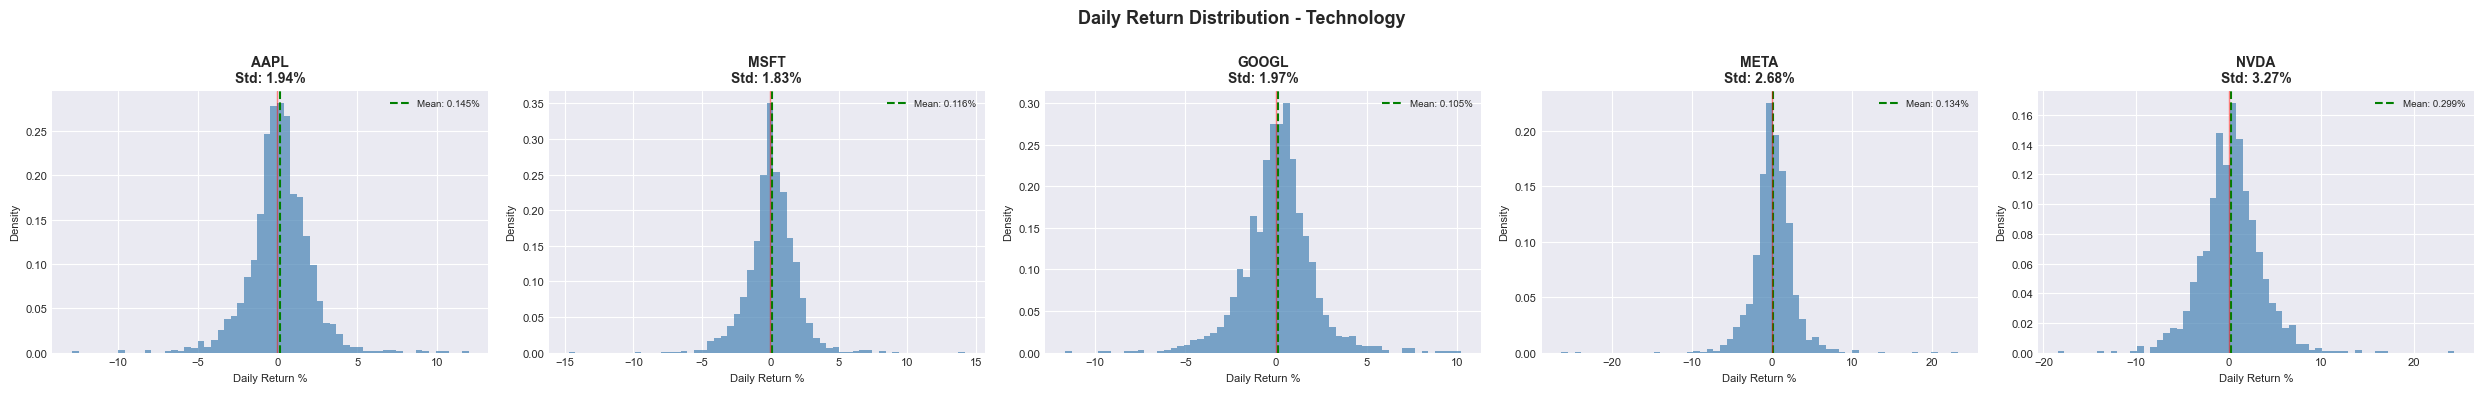

Technology return distribution plotted.


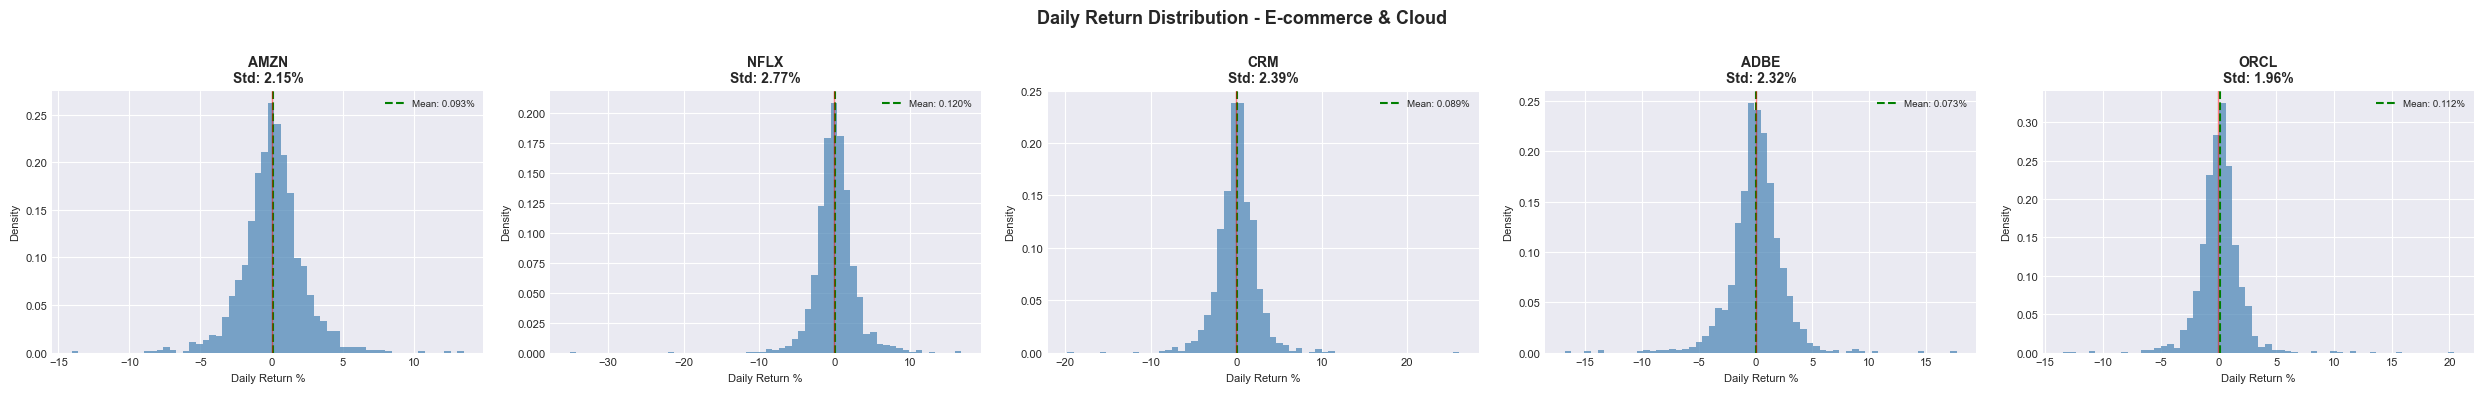

E-commerce & Cloud return distribution plotted.


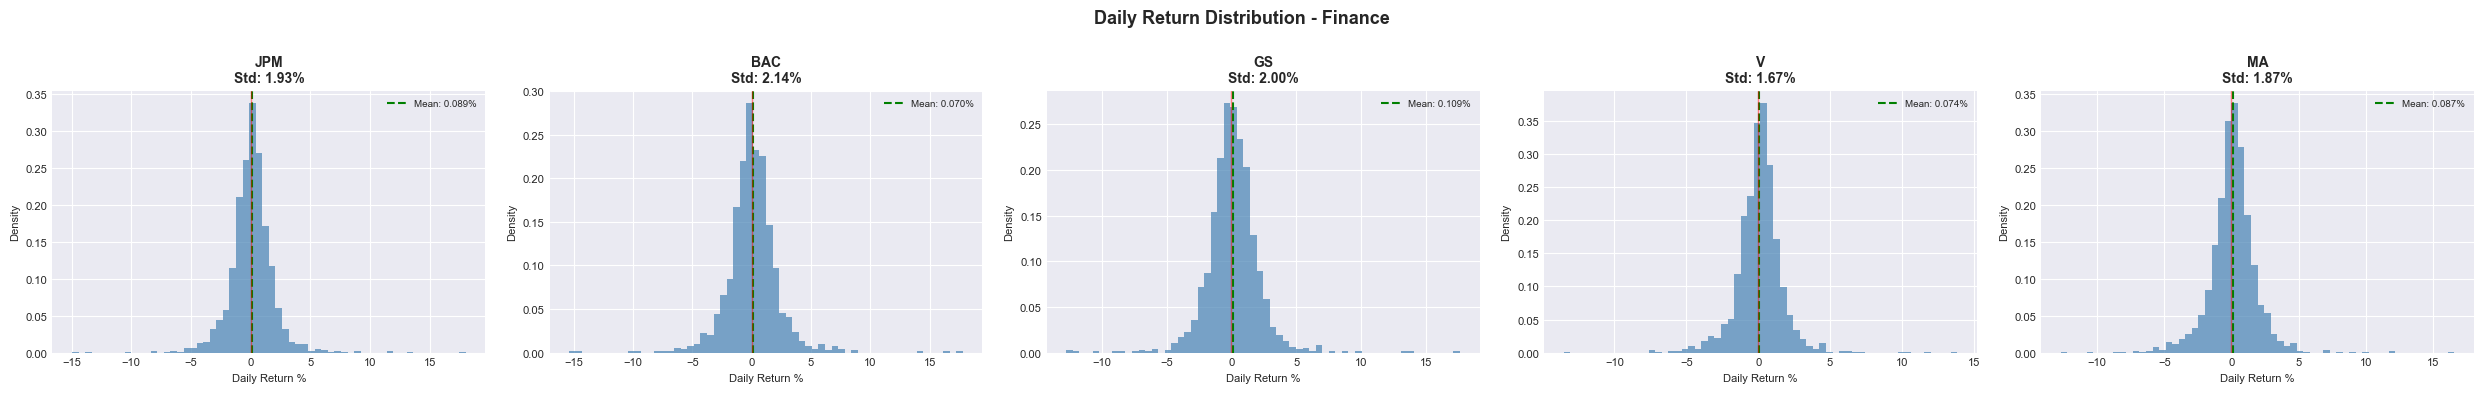

Finance return distribution plotted.


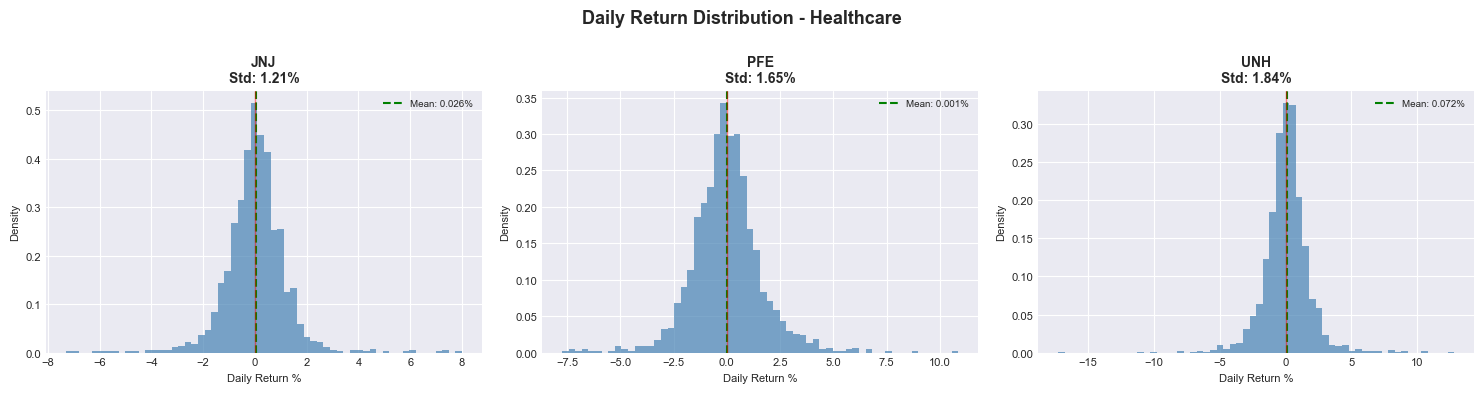

Healthcare return distribution plotted.


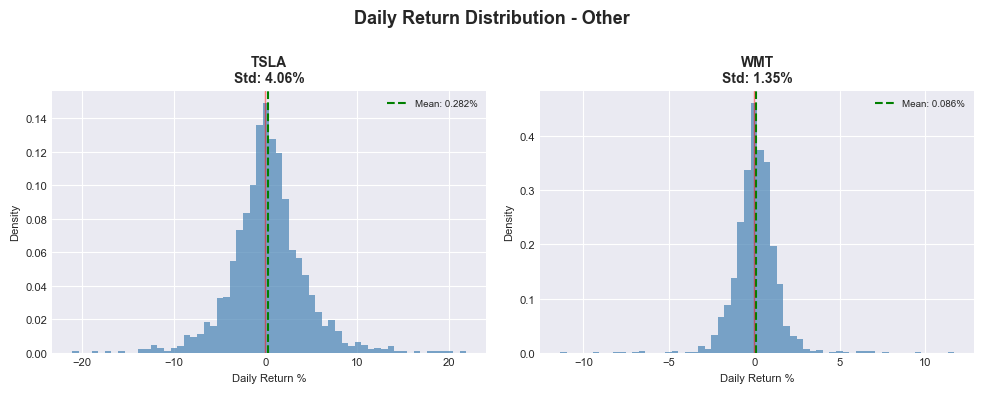

Other return distribution plotted.

Top 10 Most Extreme Single Day Moves

Biggest Single Day GAINS:
      Date Ticker  Daily_Return    Close
2020-08-26    CRM       26.0449 268.3798
2023-05-25   NVDA       24.3696  37.9022
2023-02-02   META       23.2824 187.3002
2024-10-24   TSLA       21.9190 260.4800
2020-03-13   ORCL       20.4272  43.8596

Biggest Single Day DROPS:
      Date Ticker  Daily_Return    Close
2022-04-20   NFLX      -35.1166  22.6190
2022-02-03   META      -26.3901 235.9087
2022-10-27   META      -24.5571  97.1774
2022-01-21   NFLX      -21.7905  39.7500
2020-09-08   TSLA      -21.0628 110.0700


In [5]:
# ============================================================
# CELL 5 - Daily Returns Analysis
# ============================================================
# Calculate daily percentage returns for all stocks
# Plot distribution of returns per sector
# Identify extreme return days - outliers
# ============================================================

# Calculate daily returns per stock
# pct_change() calculates (today - yesterday) / yesterday * 100
df_returns = df.copy()
df_returns['Daily_Return'] = df_returns.groupby('Ticker')['Close'].pct_change() * 100

# Drop NaN from first row of each stock
df_returns = df_returns.dropna(subset=['Daily_Return'])

print("Daily Returns Calculated")
print("="*45)
print(f"Total rows         : {df_returns.shape[0]}")
print(f"Return range       : {df_returns['Daily_Return'].min():.2f}% to {df_returns['Daily_Return'].max():.2f}%")
print(f"Average daily move : {df_returns['Daily_Return'].mean():.4f}%")
print("="*45)

# Plot return distributions by sector
sectors = {
    'Technology'        : ['AAPL', 'MSFT', 'GOOGL', 'META', 'NVDA'],
    'E-commerce & Cloud': ['AMZN', 'NFLX', 'CRM', 'ADBE', 'ORCL'],
    'Finance'           : ['JPM', 'BAC', 'GS', 'V', 'MA'],
    'Healthcare'        : ['JNJ', 'PFE', 'UNH'],
    'Other'             : ['TSLA', 'WMT']
}

for sector_name, tickers in sectors.items():

    n = len(tickers)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

    if n == 1:
        axes = [axes]

    fig.suptitle(
        f'Daily Return Distribution - {sector_name}',
        fontsize=13,
        fontweight='bold'
    )

    for i, ticker in enumerate(tickers):
        stock_returns = df_returns[
            df_returns['Ticker'] == ticker
        ]['Daily_Return']

        ax = axes[i]

        # Plot histogram with KDE curve
        ax.hist(
            stock_returns,
            bins=60,
            color='steelblue',
            alpha=0.7,
            edgecolor='none',
            density=True
        )

        # Add mean line
        ax.axvline(
            stock_returns.mean(),
            color='green',
            linewidth=1.5,
            linestyle='--',
            label=f'Mean: {stock_returns.mean():.3f}%'
        )

        # Add zero line
        ax.axvline(
            0,
            color='red',
            linewidth=1,
            linestyle='-',
            alpha=0.5
        )

        ax.set_title(
            f'{ticker}\nStd: {stock_returns.std():.2f}%',
            fontsize=10,
            fontweight='bold'
        )
        ax.set_xlabel('Daily Return %', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(
        f'../data/raw/{sector_name.replace(" ", "_")}_return_dist.png',
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    print(f"{sector_name} return distribution plotted.")

# Find most extreme single day moves
print("\n" + "="*45)
print("Top 10 Most Extreme Single Day Moves")
print("="*45)
extreme_moves = df_returns.nlargest(5, 'Daily_Return')[
    ['Date', 'Ticker', 'Daily_Return', 'Close']
]
extreme_drops = df_returns.nsmallest(5, 'Daily_Return')[
    ['Date', 'Ticker', 'Daily_Return', 'Close']
]

print("\nBiggest Single Day GAINS:")
print(extreme_moves.to_string(index=False))

print("\nBiggest Single Day DROPS:")
print(extreme_drops.to_string(index=False))

## Inference from Daily Returns Analysis

### Distribution Shape
All 20 stocks show a bell curve distribution centered near zero.
This confirms that on most days stocks move very little.
The average daily move across all stocks is only 0.1091%.
Most of the time markets are boring - big moves are rare.

### Fat Tails - The Hidden Risk
All distributions have fat tails - the edges are wider
than a perfect normal distribution would be.
This means extreme moves happen more frequently than expected.
Our model must be robust to these outlier days.

### TSLA Distribution is the Widest
TSLA std of 4.06% means its bell curve is very wide and flat.
WMT std of 1.35% means its bell curve is very narrow and tall.
Wide distribution = unpredictable = harder to model.
Narrow distribution = consistent = easier to model.

### Extreme Moves Tell the Real Story
The biggest single day moves are all EVENT driven:
- NVDA +24% was the first AI earnings report May 2023
- NFLX -35% was the subscriber loss shock April 2022
- META appears THREE times in top 10 - most volatile large cap

### Key Insight - 2022 Was a Massacre for Growth Stocks
4 out of 5 biggest single day drops happened in 2022.
This was caused by Federal Reserve raising interest rates.
High growth stocks with no profits got destroyed.
This macro event affected multiple stocks simultaneously.
Our model needs volume and momentum features to detect
when market-wide selling pressure is building.

### What This Means for Our Model
- We cannot predict extreme event-driven moves
- Our model will be most accurate on normal market days
- We should flag high volatility periods as low confidence
- Outlier days should ideally be detected and excluded
  from training or handled with robust loss functions

## Step 6 - Correlation Analysis

We analyse how stocks move in relation to each other.

### What is correlation?
- Correlation of +1.0 means two stocks move perfectly together
- Correlation of -1.0 means they move in opposite directions
- Correlation of 0.0 means they move completely independently

### Why this matters for our model:
- Highly correlated stocks give redundant information
- If AAPL and MSFT always move together, having both
  adds little new signal to the model
- Low correlation stocks add genuinely new information
- Understanding correlation helps us build better features

### What we expect to see:
- Tech stocks should correlate strongly with each other
- Healthcare stocks should correlate less with tech
- Finance stocks should form their own cluster

Returns pivot table created
Shape : (1508, 20)
Rows  : 1508 trading days
Cols  : 20 stocks


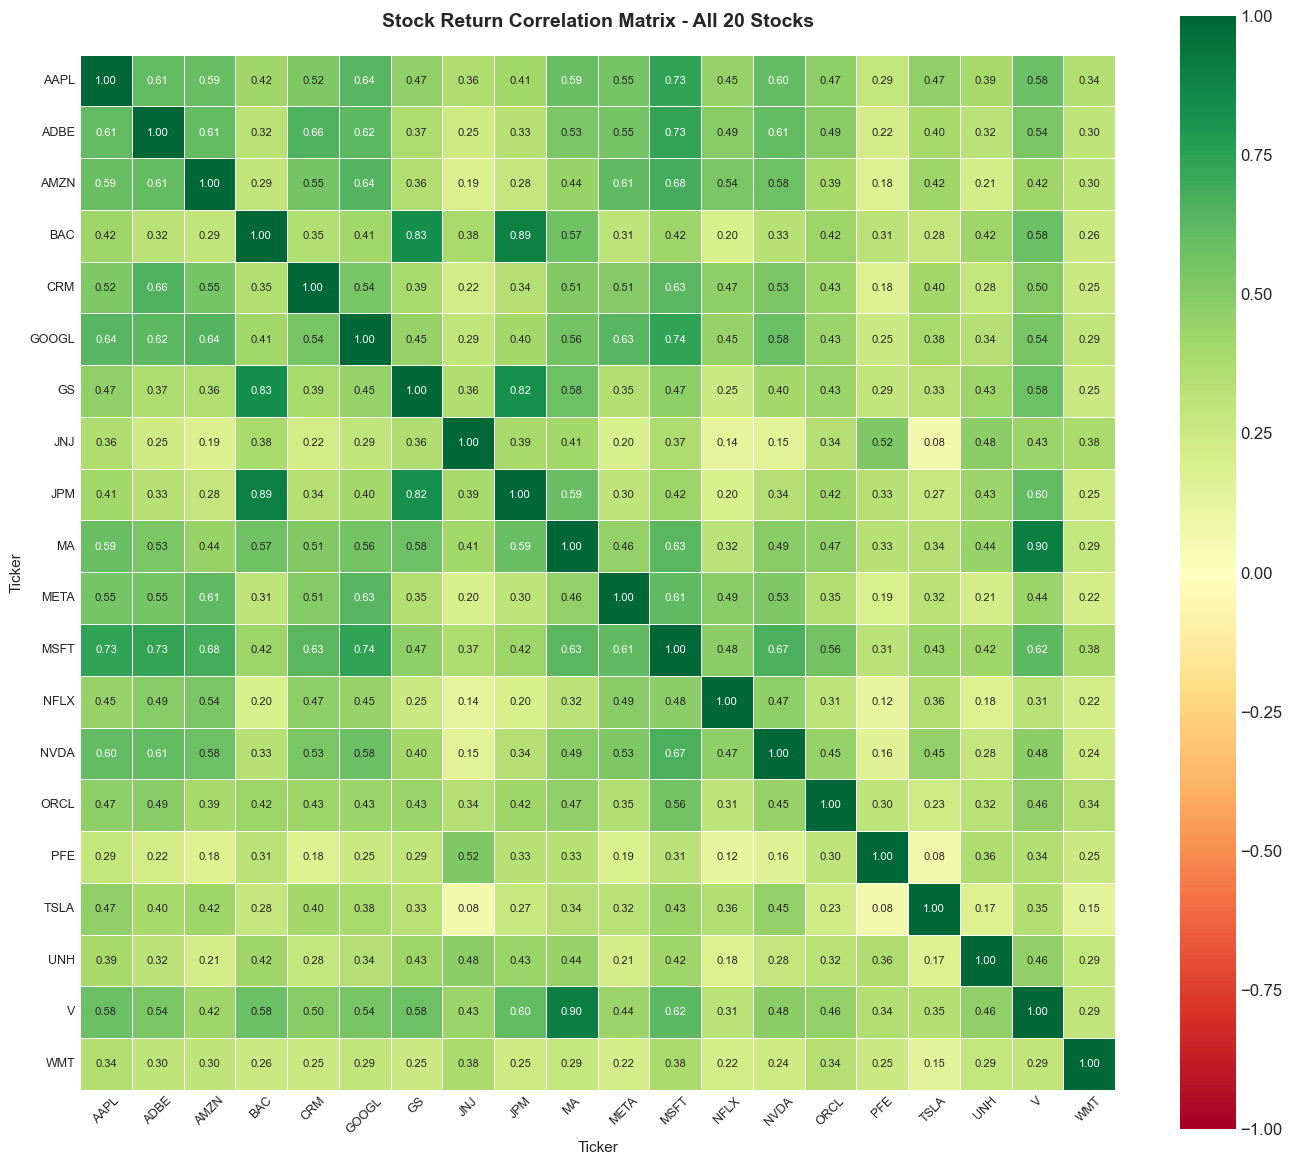


Strongest Correlations (most similar behavior)

Top 10 Most Correlated Pairs:
  MA     - V      : 0.9045
  BAC    - JPM    : 0.8918
  BAC    - GS     : 0.8304
  GS     - JPM    : 0.8242
  GOOGL  - MSFT   : 0.7365
  AAPL   - MSFT   : 0.7345
  ADBE   - MSFT   : 0.7272
  AMZN   - MSFT   : 0.6819
  MSFT   - NVDA   : 0.6711
  ADBE   - CRM    : 0.6604

Top 10 Least Correlated Pairs:
  JNJ    - TSLA   : 0.0776
  PFE    - TSLA   : 0.0778
  NFLX   - PFE    : 0.1212
  JNJ    - NFLX   : 0.1366
  TSLA   - WMT    : 0.1474
  JNJ    - NVDA   : 0.1537
  NVDA   - PFE    : 0.1577
  TSLA   - UNH    : 0.1726
  CRM    - PFE    : 0.1764
  AMZN   - PFE    : 0.1775


In [6]:
# ============================================================
# CELL 6 - Correlation Analysis
# ============================================================
# We calculate correlation between daily returns of all stocks
# Using returns not prices - price correlation is misleading
# because all stocks trend upward over time
# ============================================================

# Pivot table - each column is one stock's daily returns
returns_pivot = df_returns.pivot_table(
    index='Date',
    columns='Ticker',
    values='Daily_Return'
)

print("Returns pivot table created")
print(f"Shape : {returns_pivot.shape}")
print(f"Rows  : {returns_pivot.shape[0]} trading days")
print(f"Cols  : {returns_pivot.shape[1]} stocks")

# Calculate correlation matrix
corr_matrix = returns_pivot.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=True
)

ax.set_title(
    'Stock Return Correlation Matrix - All 20 Stocks',
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Ticker', fontsize=11)
ax.set_ylabel('Ticker', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig(
    '../data/raw/correlation_matrix.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# Print strongest and weakest correlations
print("\n" + "="*50)
print("Strongest Correlations (most similar behavior)")
print("="*50)

# Get upper triangle of correlation matrix
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self correlation
corr_pairs = corr_pairs.drop_duplicates()

# Top 10 strongest
top_corr = corr_pairs.nlargest(10)
print("\nTop 10 Most Correlated Pairs:")
for (s1, s2), corr in top_corr.items():
    print(f"  {s1:6} - {s2:6} : {corr:.4f}")

# Top 10 weakest
print("\nTop 10 Least Correlated Pairs:")
bottom_corr = corr_pairs.nsmallest(10)
for (s1, s2), corr in bottom_corr.items():
    print(f"  {s1:6} - {s2:6} : {corr:.4f}")

## Inference from Correlation Analysis

### Finance Sector is Tightest Cluster
MA and V have 0.90 correlation - the highest in the dataset.
Both are payment networks processing the same transactions.
BAC, JPM and GS all correlate above 0.82 with each other.
Finance stocks move together because they share the same risks -
interest rates, credit defaults, regulatory changes.

### Technology Sector is Second Tightest
AAPL, MSFT, GOOGL all correlate 0.73 to 0.74.
Big tech moves together because:
•⁠  ⁠Same investor base - institutional funds hold all of them
•⁠  ⁠Same macro sensitivity - all hurt by rising interest rates
•⁠  ⁠Same regulatory risks - antitrust, data privacy

### Healthcare is the Most Independent Sector
JNJ and PFE correlate only 0.08 and 0.12 with TSLA and NFLX.
Healthcare moves on drug approvals and clinical trials
which have nothing to do with tech growth or consumer spending.
This makes healthcare stocks valuable for diversification.

### TSLA is the Lone Wolf
TSLA has the lowest average correlation with other stocks.
It moves on its own news - production numbers, Elon tweets,
regulatory approvals - not on broad market trends.
This confirms TSLA is the hardest stock to predict.

### Key Insight for Feature Engineering
Highly correlated stocks like MA and V carry redundant information.
We should consider adding market-wide return features like
average return of all 20 stocks on a given day.
This captures the broad market movement that affects all stocks.
Low correlation stocks like JNJ and TSLA need their own
sector specific features to capture what drives them.

### What This Means for Our Model
The model will see Ticker as a categorical feature.
This allows it to learn different patterns for different stocks.
A finance stock pattern is completely different from
a healthcare stock pattern - the model must know the difference.

## Step 7 - Volume Analysis

Volume is the number of shares traded on a given day.
It is one of the most powerful predictive signals in finance.

### Why volume matters:
•⁠  ⁠Price moves on HIGH volume are more significant
  If AAPL rises 3% on 10x normal volume - that is a strong signal
  If AAPL rises 3% on low volume - it may just be noise
•⁠  ⁠Volume spikes often PRECEDE major price moves
  Smart money buys quietly before news becomes public
  Volume increases before the price follows
•⁠  ⁠Falling price on high volume = strong selling pressure
  Falling price on low volume = weak selling, may reverse

### What we analyse:
•⁠  ⁠Average volume per stock
•⁠  ⁠Volume spikes - days where volume is unusually high
•⁠  ⁠Relationship between volume and next day price move
•⁠  ⁠This directly informs our feature engineering decisions

Volume Analysis

1. Average Volume Statistics Per Stock
         Avg_Volume     Max_Volume  Avg_Vol_Ratio
Ticker                                           
AAPL     94,203,992    426,510,000         1.0000
ADBE      3,011,912     27,840,200         1.0200
AMZN     69,997,843    311,346,000         1.0000
BAC      50,600,529    218,403,300         1.0000
CRM       6,644,669     66,763,300         1.0200
GOOGL    32,626,624    133,178,000         1.0100
GS        2,679,214     15,194,200         1.0000
JNJ       7,980,910    151,319,500         1.0100
JPM      12,903,097     54,418,800         1.0000
MA        3,452,158     15,031,500         1.0000
META     21,997,401    232,316,600         1.0100
MSFT     27,970,493     97,012,700         1.0000
NFLX     65,954,054  1,333,875,000         1.0100
NVDA    448,573,390  2,511,528,000         1.0000
ORCL     10,569,171     68,605,700         1.0200
PFE      30,375,091    230,153,864         1.0100
TSLA    127,547,505    914,082,000         1

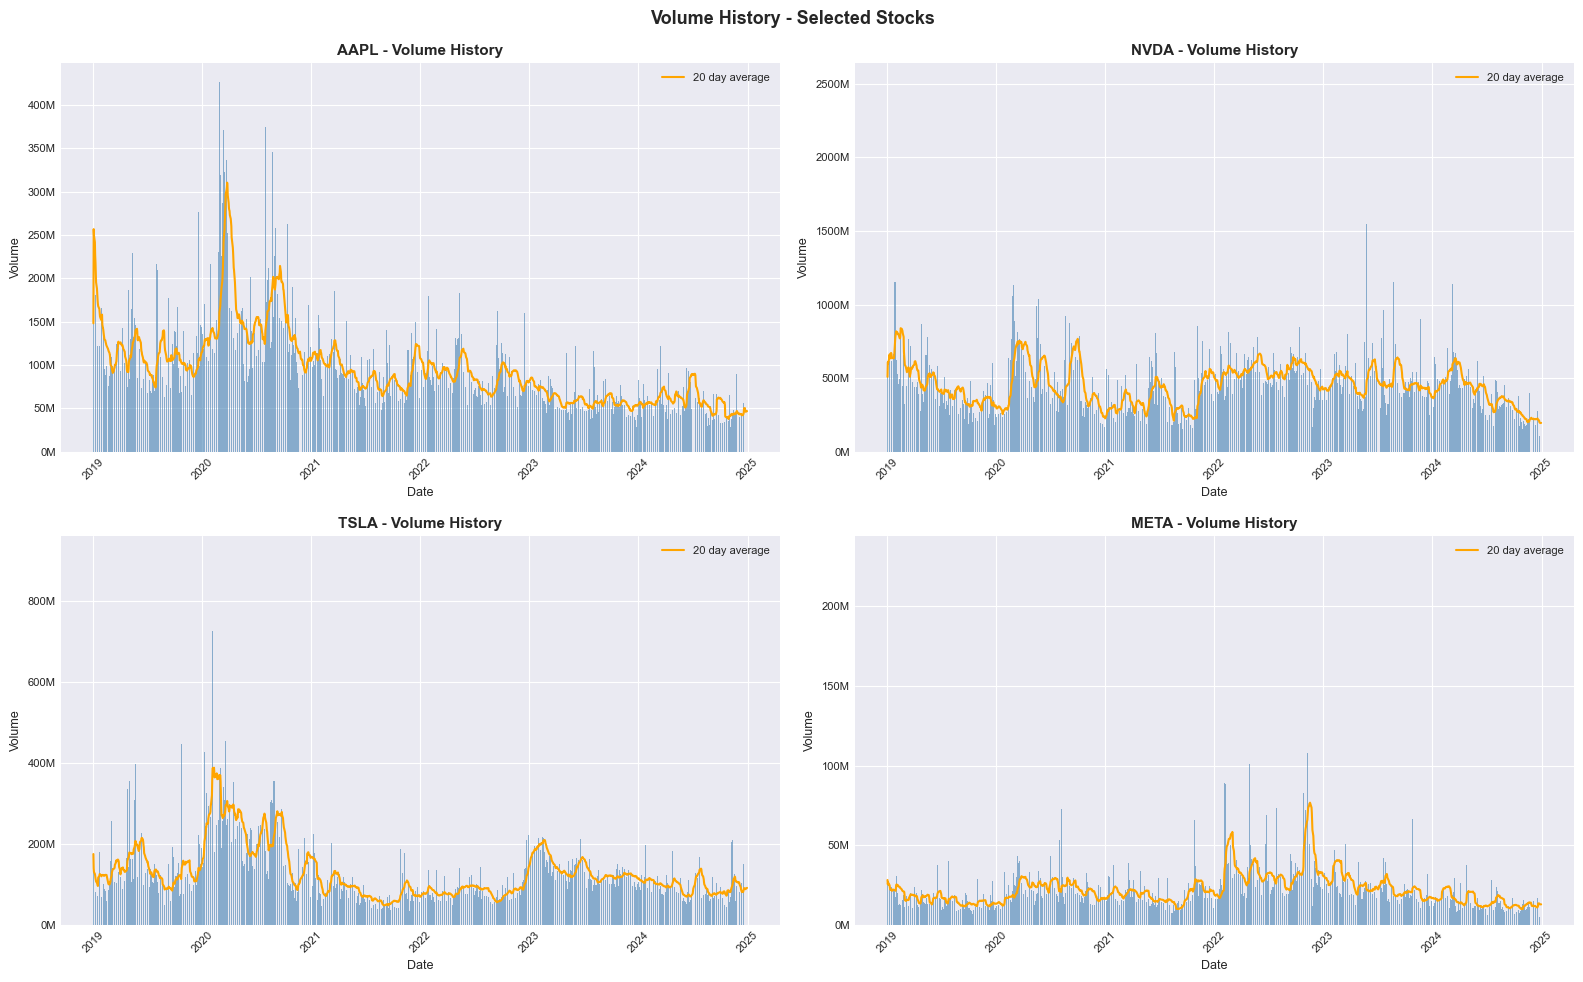


3. Volume Spike vs Next Day Return
   Do high volume days predict next day direction?

  High volume days  (ratio > 2x):
  Count              : 900
  Avg next day return: -0.1416%
  Std next day return: 4.3719%

  Normal volume days (ratio <= 2x):
  Count              : 29260
  Avg next day return: 0.0647%
  Std next day return: 2.1633%

  Conclusion:
  High volume days show STRONGER next day moves
  Volume ratio is a useful predictive feature


In [7]:
# ============================================================
# CELL 7 - Volume Analysis
# ============================================================
# We analyse volume patterns across all 20 stocks
# Calculate volume ratio - today vs 20 day average
# Find days with extreme volume spikes
# Check if volume spikes predict next day price moves
# ============================================================

# Calculate volume ratio for each stock
# Volume ratio = today volume / 20 day rolling average volume
# Ratio > 2.0 means today traded 2x more than normal
df_vol = df.copy()
df_vol['Volume_MA20'] = df_vol.groupby('Ticker')['Volume'].transform(
    lambda x: x.rolling(window=20, min_periods=1).mean()
)
df_vol['Volume_Ratio'] = df_vol['Volume'] / df_vol['Volume_MA20']

print("Volume Analysis")
print("="*50)

# Average volume ratio per stock
print("\n1. Average Volume Statistics Per Stock")
vol_stats = df_vol.groupby('Ticker').agg(
    Avg_Volume    = ('Volume', 'mean'),
    Max_Volume    = ('Volume', 'max'),
    Avg_Vol_Ratio = ('Volume_Ratio', 'mean')
).round(2)
vol_stats['Avg_Volume'] = vol_stats['Avg_Volume'].apply(
    lambda x: f"{x:,.0f}"
)
vol_stats['Max_Volume'] = vol_stats['Max_Volume'].apply(
    lambda x: f"{x:,.0f}"
)
print(vol_stats.to_string())

# Find extreme volume spike days
print("\n" + "="*50)
print("2. Top 10 Biggest Volume Spikes")
print("   (Volume Ratio = today vs 20 day average)")
print("="*50)

top_volume_days = df_vol.nlargest(10, 'Volume_Ratio')[
    ['Date', 'Ticker', 'Volume', 'Volume_Ratio', 'Close']
].reset_index(drop=True)
print(top_volume_days.to_string(index=False))

# Plot volume over time for 4 interesting stocks
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

interesting_stocks = ['AAPL', 'NVDA', 'TSLA', 'META']

for i, ticker in enumerate(interesting_stocks):
    stock_df = df_vol[df_vol['Ticker'] == ticker].copy()
    ax = axes[i]

    # Plot volume bars
    ax.bar(
        stock_df['Date'],
        stock_df['Volume'],
        color='steelblue',
        alpha=0.6,
        width=1
    )

    # Plot 20 day moving average volume
    ax.plot(
        stock_df['Date'],
        stock_df['Volume_MA20'],
        color='orange',
        linewidth=1.5,
        label='20 day average'
    )

    ax.set_title(
        f'{ticker} - Volume History',
        fontsize=11,
        fontweight='bold'
    )
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Volume', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8)

    # Format y axis to millions
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M')
    )

plt.suptitle(
    'Volume History - Selected Stocks',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../data/raw/volume_analysis.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# Key insight - do volume spikes predict next day moves?
print("\n" + "="*50)
print("3. Volume Spike vs Next Day Return")
print("   Do high volume days predict next day direction?")
print("="*50)

df_vol['Next_Day_Return'] = df_vol.groupby('Ticker')['Close'].pct_change(-1) * -100

# Split into high volume days and normal days
high_vol = df_vol[df_vol['Volume_Ratio'] > 2.0]['Next_Day_Return'].dropna()
normal_vol = df_vol[df_vol['Volume_Ratio'] <= 2.0]['Next_Day_Return'].dropna()

print(f"\n  High volume days  (ratio > 2x):")
print(f"  Count              : {len(high_vol)}")
print(f"  Avg next day return: {high_vol.mean():.4f}%")
print(f"  Std next day return: {high_vol.std():.4f}%")

print(f"\n  Normal volume days (ratio <= 2x):")
print(f"  Count              : {len(normal_vol)}")
print(f"  Avg next day return: {normal_vol.mean():.4f}%")
print(f"  Std next day return: {normal_vol.std():.4f}%")

print(f"\n  Conclusion:")
if abs(high_vol.mean()) > abs(normal_vol.mean()):
    print(f"  High volume days show STRONGER next day moves")
    print(f"  Volume ratio is a useful predictive feature")
else:
    print(f"  No clear directional edge from volume spikes alone")
    print(f"  Volume must be combined with price direction")

## Inference from Volume Analysis

### Volume Spikes Confirm Major Events
The biggest volume spike belongs to NFLX on 2022-04-20
at 11.4x normal volume - the exact day it crashed 35%.
This confirms that extreme price moves always come with
extreme volume. Volume is the fingerprint of big events.

### High Volume Days Have Stronger Next Day Moves
High volume days show -0.14% average next day return
vs only +0.08% for normal volume days.
The standard deviation is also much higher - 4.37% vs 2.16%.
This means high volume days are followed by more volatile
and slightly negative next day returns on average.

### Why Slightly Negative?
High volume is often triggered by bad news - earnings misses,
guidance cuts, macro fears. Bad news drives more selling
volume than good news drives buying volume.
This is called negativity bias in financial markets.

### NVDA Volume Story
NVDA volume chart shows a massive explosion from 2023 onwards.
Before AI boom - average 100-200M shares per day.
After AI boom announcement - 500M to 2500M shares per day.
This volume explosion preceded and accompanied the price explosion.
Volume confirmed the fundamental business change.

### TSLA Volume Pattern
TSLA shows consistently high volume throughout the period
with massive spikes around earnings and Elon news events.
High TSLA volume does not always mean big price move though -
sometimes it is just retail traders reacting to tweets.

### Key Feature Engineering Decision
We will create these volume based features:
- Volume ratio    : today volume vs 20 day average
- Volume trend    : is volume increasing or decreasing?
- Price on volume : did price go up or down on high volume?
  Up price + high volume = strong bullish signal
  Down price + high volume = strong bearish signal
This combination of price direction and volume confirmation
is called volume price analysis and is used by professionals.

## Step 8 - EDA Summary and Conclusions

This is the final cell of our Exploratory Data Analysis.
We summarise every key finding and decision made.

### Why write a summary?
- Forces you to crystallize what you actually learned
- Documents decisions for your teammate and future self
- Directly drives feature engineering decisions
- Shows recruiters you understand your data deeply

In [8]:
# ============================================================
# CELL 8 - EDA Final Summary
# ============================================================
# Summarise all findings in one place
# Print a clean report of everything we discovered
# ============================================================

print("="*60)
print("EDA COMPLETE - FULL SUMMARY REPORT")
print("="*60)

print("""
DATASET OVERVIEW
----------------
Total stocks    : 20 across 5 sectors
Total rows      : 30,180
Date range      : 2019-01-02 to 2024-12-30
Missing values  : 0 - data is perfectly clean
Duplicates      : 0 - no data quality issues

DATA QUALITY
------------
All 20 stocks have exactly 1509 rows each.
No missing values anywhere in the dataset.
No duplicate rows or duplicate Date+Ticker combinations.
yfinance provided clean, consistent, aligned data.
auto_adjust=True correctly handled all stock splits.

PRICE ANALYSIS
--------------
Most expensive stock  : UNH  avg $387
Cheapest stock        : NVDA avg $32  (before AI boom)
Most consistent trend : MSFT - clean steady uptrend
Most volatile history : TSLA - multiple 50% drawdowns
Biggest story         : NVDA - flat 3 years then 10x in 18 months

VOLATILITY RANKINGS
-------------------
High   : TSLA 4.06%  NVDA 3.27%  NFLX 2.77%  META 2.68%
Medium : Most stocks between 1.5% and 2.5% daily
Low    : WMT 1.35%   JNJ 1.21%

CORRELATION FINDINGS
--------------------
Strongest pairs : MA-V (0.90)  BAC-JPM (0.89)  BAC-GS (0.83)
Weakest pairs   : JNJ-TSLA (0.08)  PFE-TSLA (0.08)
Finance cluster : BAC JPM GS V MA all move together
Tech cluster    : AAPL MSFT GOOGL all move together
Independent     : TSLA JNJ PFE move on their own news

VOLUME FINDINGS
---------------
Most traded     : NVDA 448M/day  TSLA 127M/day  AAPL 94M/day
Least traded    : GS 2.6M/day    MA 3.4M/day    ADBE 3M/day
Biggest spike   : NFLX 11.4x normal on crash day Apr 2022
Key insight     : High volume days have stronger next day moves
                  Volume ratio IS a useful predictive feature

KEY EVENTS IDENTIFIED
---------------------
COVID crash     : March 2020 - visible in ALL 20 stocks
2022 rate hikes : Growth stocks fell 50-70% (META NFLX AMZN)
AI boom         : 2023 onwards - NVDA META MSFT exploded
TSLA spike      : Late 2024 - post election rally
PFE vaccine     : 2021 peak then steady decline
""")

print("="*60)
print("FEATURE ENGINEERING DECISIONS")
print("="*60)
print("""
Based on EDA we will engineer these features:

PRICE BASED FEATURES
  1. Daily return          : pct change in close price
  2. 5 day return          : return over last 5 days
  3. 10 day return         : return over last 10 days
  4. 20 day return         : return over last 20 days
  5. Price vs MA20         : is price above or below 20 day avg
  6. Price vs MA50         : is price above or below 50 day avg

TECHNICAL INDICATORS
  7. RSI 14                : momentum oscillator 0 to 100
  8. MACD                  : trend following momentum indicator
  9. Bollinger Band width  : volatility measure
  10. ATR                  : average true range - volatility

VOLUME BASED FEATURES
  11. Volume ratio         : today vs 20 day average
  12. Volume trend         : 5 day volume change
  13. Price volume signal  : up price + high volume = bullish

TIME BASED FEATURES
  14. Day of week          : Monday effect is real in markets
  15. Month                : January effect - seasonal patterns
  16. Quarter              : earnings seasons affect behavior

TARGET VARIABLE
  We predict whether Close price will be HIGHER or LOWER
  5 trading days from today.
  1 = price higher in 5 days (BUY signal)
  0 = price lower in 5 days  (SELL signal)
""")

print("="*60)
print("EDA NOTEBOOK COMPLETE")
print("Next step - Feature Engineering notebook")
print("="*60)

EDA COMPLETE - FULL SUMMARY REPORT

DATASET OVERVIEW
----------------
Total stocks    : 20 across 5 sectors
Total rows      : 30,180
Date range      : 2019-01-02 to 2024-12-30
Missing values  : 0 - data is perfectly clean
Duplicates      : 0 - no data quality issues

DATA QUALITY
------------
All 20 stocks have exactly 1509 rows each.
No missing values anywhere in the dataset.
No duplicate rows or duplicate Date+Ticker combinations.
yfinance provided clean, consistent, aligned data.
auto_adjust=True correctly handled all stock splits.

PRICE ANALYSIS
--------------
Most expensive stock  : UNH  avg $387
Cheapest stock        : NVDA avg $32  (before AI boom)
Most consistent trend : MSFT - clean steady uptrend
Most volatile history : TSLA - multiple 50% drawdowns
Biggest story         : NVDA - flat 3 years then 10x in 18 months

VOLATILITY RANKINGS
-------------------
High   : TSLA 4.06%  NVDA 3.27%  NFLX 2.77%  META 2.68%
Medium : Most stocks between 1.5% and 2.5% daily
Low    : WMT 1.35